# 🚀 Day 8: Logistic Regression

## 30 Days of Machine Learning Challenge

Today I am moving from regression to classification.

I will use Logistic Regression to predict whether a student
belongs to a High Performance or Low Performance category.

### Objectives

- Understand classification
- Understand Logistic Regression
- Create a categorical target
- Prepare features and target
- Perform Train-Test Split
- Train a Logistic Regression model
- Make predictions
- Evaluate classification performance
- Understand confusion matrix
- Calculate accuracy, precision, recall and F1-score

In [4]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [5]:
#Load Dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
#Explore Dataset
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (6607, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              66

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
#Create Classification Target
df["Performance"] = (
    df["Exam_Score"] >= 75
).astype(int)

Here:

1 → High Performance
0 → Low Performance

Check it:

In [8]:
print(df[["Exam_Score", "Performance"]].head(10))

   Exam_Score  Performance
0          67            0
1          61            0
2          74            0
3          71            0
4          70            0
5          71            0
6          67            0
7          66            0
8          69            0
9          72            0


In [9]:
#Check Class Distribution
print(df["Performance"].value_counts())

Performance
0    6483
1     124
Name: count, dtype: int64


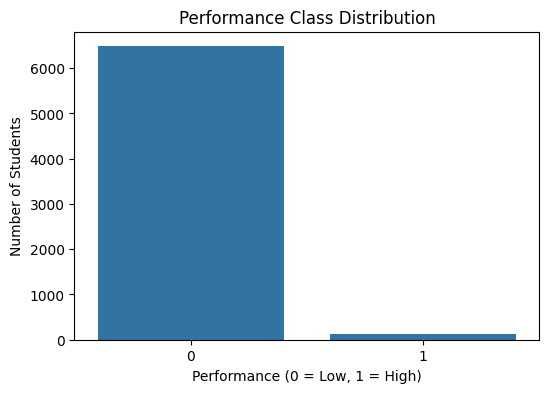

In [10]:
#Visualize:
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Performance",
    data=df
)

plt.title("Performance Class Distribution")
plt.xlabel("Performance (0 = Low, 1 = High)")
plt.ylabel("Number of Students")

plt.show()

In [11]:
#Select Features
features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Sleep_Hours",
    "Tutoring_Sessions"
]

X = df[features]

y = df["Performance"]

In [12]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Why stratify=y?

It helps maintain a similar proportion of the two classes in both training and testing datasets.

In [13]:
#Create Logistic Regression Model
model = LogisticRegression(
    max_iter=1000
)

In [14]:
#Train the Model
model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [15]:
#Make Predictions
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [16]:
#Actual vs Predicted
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,1,0
8,0,0
9,0,0


In [17]:
#Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
#Accuracy tells us the proportion of predictions that were correct.

Accuracy: 0.9818456883509834


In [18]:
#precision
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)
#Precision answers:
#Of the students predicted as high performers, how many were actually high performers?

Precision: 1.0


In [19]:
#Recall

recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)
#Recall answers: Of all actual high-performing students, how many did the model correctly identify?

Recall: 0.04


In [20]:
#F1 Score
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)
#F1 combines precision and recall into a single metric.

F1 Score: 0.07692307692307693


In [21]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1297
           1       1.00      0.04      0.08        25

    accuracy                           0.98      1322
   macro avg       0.99      0.52      0.53      1322
weighted avg       0.98      0.98      0.97      1322



In [22]:
# Cnfusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1297    0]
 [  24    1]]


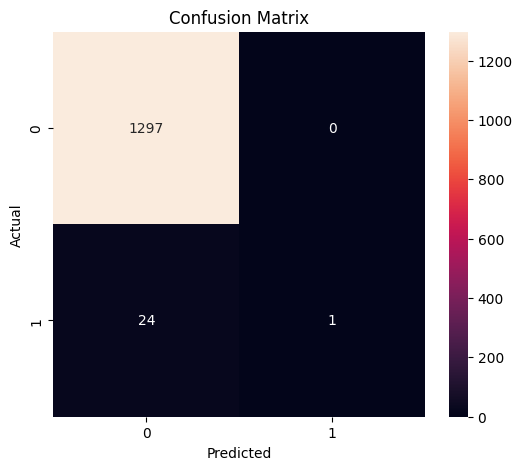

In [23]:
#Visualize
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Understand Confusion Matrix
                      
        Predicted
                  0          1
Actual
        0        TN         FP

        1        FN         TP

Where:

- TN → True Negative
- FP → False Positive
- FN → False Negative
- TP → True Positive

In [24]:
#Model Coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

#sort them
coefficients.sort_values(
    "Coefficient",
    ascending=False
)

,Feature,Coefficient
4,Tutoring_Sessions,0.318583
0,Hours_Studied,0.181069
1,Attendance,0.068862
2,Previous_Scores,0.010373
3,Sleep_Hours,-0.026004


In [25]:
# Predict a New Student
new_student = pd.DataFrame({
    "Hours_Studied": [6],
    "Attendance": [90],
    "Previous_Scores": [75],
    "Sleep_Hours": [7],
    "Tutoring_Sessions": [2]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Predicted Performance: High")
else:
    print("Predicted Performance: Low")

Predicted Performance: Low


In [26]:
#Prediction Probability: Logistic Regression can also provide probabilities.
probability = model.predict_proba(
    new_student
)

print(probability)

[[0.99856616 0.00143384]]


## 💡 Key Learning

Logistic Regression is used for classification problems.

Unlike Linear Regression, which predicts a continuous value,
Logistic Regression predicts the probability of belonging to a class.

In this project:

0 → Low Performance
1 → High Performance

Important evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix